# XGBoost 实验（独立版）

**场站**: Project1033（正常场站，CF峰值13:00，无clipping）

**配置**: PV + NWP + 时间编码，24h lookback → 预测未来 24h (144 个 10min 步)

**GPU**: A100/T4 自动检测（XGBoost tree_method='hist', device='cuda'）

**本 notebook 完全独立**，不依赖线性回归的缓存，从原始 CSV 开始处理。

运行方式：从上到下依次执行每个 cell

## Step 0：环境设置

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time
PROJECT_DIR = '/content/drive/MyDrive/SolarPrediction'
os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

assert os.path.exists(PROJECT_DIR), f'❌ 路径不存在: {PROJECT_DIR}'
assert os.path.exists(os.path.join(PROJECT_DIR, 'data', 'Project1033.csv')), '❌ 找不到 Project1033.csv'
print(f'✅ 项目路径: {PROJECT_DIR}')
print(f'✅ 数据文件: data/Project1033.csv')

Mounted at /content/drive
✅ 项目路径: /content/drive/MyDrive/SolarPrediction
✅ 数据文件: data/Project1033.csv


In [ ]:
!pip install -q xgboost lightgbm rich

In [ ]:
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'显存    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print('✅ XGBoost 将自动使用 GPU (tree_method=hist, device=cuda)')
else:
    print('⚠️  GPU 未检测到，将使用 CPU 训练（速度较慢）')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-40GB
显存    : 42.4 GB
✅ XGBoost 将自动使用 GPU (tree_method=hist, device=cuda)


## Step 1：加载数据 + 过滤

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data_path = os.path.join(PROJECT_DIR, 'data', 'Project1033.csv')

t0 = time.time()
df_raw = pd.read_csv(data_path)
df_raw['Datetime'] = pd.to_datetime(df_raw['date'])

# Filter 1: 仅保留2022+（pred列只有2022年后有数据）
before = len(df_raw)
df_raw = df_raw[df_raw['Datetime'].dt.year >= 2022].reset_index(drop=True)
print(f'Filter 1 (2022+): {before:,} → {len(df_raw):,} 行')

# Filter 2: 去除夜间irradiance异常（2024-09-27凌晨17行）
night_anom = (df_raw['Datetime'].dt.hour < 5) & \
             (df_raw['global_tilted_irradiance_pred'].fillna(0) > 5)
df_raw = df_raw[~night_anom].reset_index(drop=True)
print(f'Filter 2 (夜间异常): 去除 {night_anom.sum()} 行')

print(f'\n数据大小  : {df_raw.shape[0]:,} 行 × {df_raw.shape[1]} 列')
print(f'时间范围  : {df_raw["Datetime"].min()} → {df_raw["Datetime"].max()}')
print(f'加载耗时  : {time.time()-t0:.1f} 秒')

Filter 1 (2022+): 249,547 → 144,283 行
Filter 2 (夜间异常): 去除 17 行

数据大小  : 144,266 行 × 54 列
时间范围  : 2022-01-01 00:00:00 → 2024-09-28 23:00:00
加载耗时  : 5.4 秒


## Step 2：配置参数

**复杂度选择**（修改 `model_complexity`）：
- `'low'` → n_estimators=200, max_depth=4，预计 **10~20 分钟**（推荐先跑这个）
- `'high'` → n_estimators=800, max_depth=8，预计 **40~60 分钟**

In [ ]:
COMPLEXITY = 'low'   # 'low' ≈ 10-20min  |  'high' ≈ 40-60min（RAM 要求更高）

config = {
    'model': 'XGB',
    'model_complexity': COMPLEXITY,
    'use_pv': True,
    'use_hist_weather': False,
    'use_forecast': True,
    'use_ideal_nwp': False,
    'use_time_encoding': True,
    'weather_category': 'all_weather',
    'past_hours': 24,
    'future_hours': 24,
    'start_date': '2022-01-01',
    'end_date': '2024-09-28',
}

# 参数说明（每多 100 棵树，144 个模型 RAM 多占约 ~0.5 GB）
XGB_PARAMS = {
    'low':  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05},  # 模型总大小 ~0.7 GB
    'high': {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03},  # 模型总大小 ~1.5 GB
}
params = XGB_PARAMS[COMPLEXITY]

FUTURE_STEPS = config['future_hours'] * 6
PAST_STEPS   = config['past_hours']   * 6

print(f'模型        : XGBoost ({COMPLEXITY})')
print(f'n_estimators: {params["n_estimators"]}  × 144 个输出步 = {params["n_estimators"]*144} 棵树合计')
print(f'max_depth   : {params["max_depth"]}')

模型        : XGBoost (low)
n_estimators: 100  × 144 个输出步 = 14400 棵树合计
max_depth   : 3


## Step 3：特征工程 + 滑动窗口

独立处理，不依赖任何缓存文件：
- 筛选日期范围，清洗数据
- 添加时间编码（sin/cos）
- 把时序数据切成「输入窗口 → 预测窗口」的样本对

In [ ]:
import gc
from data.data_utils import preprocess_features, create_sliding_windows

t0 = time.time()

# 特征预处理
df_clean, hist_feats, fcst_feats, scaler_hist, scaler_fcst, scaler_target, no_hist_power = \
    preprocess_features(df_raw.copy(), config)

del df_raw
gc.collect()
print('✅ df_raw 已释放')

# 创建滑动窗口
Xh, Xf, y, hours, dates = create_sliding_windows(
    df_clean, config['past_hours'], config['future_hours'],
    hist_feats, fcst_feats, no_hist_power
)

del df_clean
gc.collect()
print('✅ df_clean 已释放')

# float64 → float32
Xh = Xh.astype(np.float32)
Xf = Xf.astype(np.float32) if Xf is not None else None
y  = y.astype(np.float32)
gc.collect()

print(f'\n滑动窗口结果:')
print(f'  历史输入 Xh : {Xh.shape}  dtype={Xh.dtype}')
print(f'  预报输入 Xf : {Xf.shape if Xf is not None else "None"}')
print(f'  预测目标 y  : {y.shape}')
print(f'耗时: {time.time()-t0:.1f} 秒')

import psutil
ram = psutil.virtual_memory()
print(f'\n内存使用: {ram.used/1e9:.1f} GB / {ram.total/1e9:.1f} GB  ({ram.percent:.0f}%)')

✅ df_raw 已释放


✅ df_clean 已释放

滑动窗口结果:
  历史输入 Xh : (143841, 144, 9)  dtype=float32
  预报输入 Xf : (143841, 144, 15)
  预测目标 y  : (143841, 144)
耗时: 359.6 秒

内存使用: 8.0 GB / 89.6 GB  (10%)


## Step 4：划分训练/验证/测试集（70/15/15 按时间顺序）

- **训练集 (70%)**: 模型学习
- **验证集 (15%)**: early stopping 监控，防止过拟合
- **测试集 (15%)**: 最终评估，训练过程中完全不使用

In [ ]:
total     = len(Xh)
train_end = int(total * 0.85)

Xh_train, Xh_test = Xh[:train_end], Xh[train_end:]
Xf_train = Xf[:train_end] if Xf is not None else None
Xf_test  = Xf[train_end:] if Xf is not None else None
y_train,  y_test  = y[:train_end],  y[train_end:]
dates_test = dates[train_end:]

print(f'总样本    : {total:,}')
print(f'训练集    : {train_end:,}  ({train_end/total*100:.0f}%)')
print(f'测试集    : {total-train_end:,}  ({(total-train_end)/total*100:.0f}%)')

# 释放完整数组
del Xh, Xf, y, dates
gc.collect()

ram = psutil.virtual_memory()
print(f'\n✅ 完整数组已释放')
print(f'当前内存: {ram.used/1e9:.1f} GB / {ram.total/1e9:.1f} GB  ({ram.percent:.0f}%)')

总样本    : 143,841
训练集    : 122,264  (85%)
测试集    : 21,577  (15%)

✅ 完整数组已释放
当前内存: 8.0 GB / 89.6 GB  (10%)


## Step 5：训练 XGBoost

XGBoost 实际训练 **144 个独立模型**（每输出步一个），A100 GPU 会大幅加速。

In [ ]:
from train.train_ml import train_ml_model

print(f'开始训练 XGBoost ({COMPLEXITY})...')
print(f'  训练样本     : {len(Xh_train):,}')
print(f'  独立模型数   : {FUTURE_STEPS}  (每个 10min 步一个 XGBoost)')
print(f'  每模型树数   : {params["n_estimators"]}')
print(f'  总树数       : {params["n_estimators"] * FUTURE_STEPS:,}')
print()

t_start = time.time()
xgb_model, xgb_metrics = train_ml_model(
    config,
    Xh_train, Xf_train, y_train,
    Xh_test,  Xf_test,  y_test,
    dates_test,
    scaler_target=scaler_target
)
train_time = time.time() - t_start

# Clip predictions to physically possible range [0, 100]
xgb_metrics['predictions'] = np.clip(xgb_metrics['predictions'], 0, 100)
xgb_metrics['y_true'] = np.clip(xgb_metrics['y_true'], 0, 100) # Ensures y_true is also within bounds for consistent comparison

print(f'\n✅ XGBoost 训练完成！')
print(f'   实际训练时间: {train_time/60:.1f} 分钟')

开始训练 XGBoost (low)...
  训练样本     : 122,264
  独立模型数   : 144  (每个 10min 步一个 XGBoost)
  每模型树数   : 100
  总树数       : 14,400



Training XGB:   0%|          | 0/200 [27:58<?, ?it/s]



✅ XGBoost 训练完成！
   实际训练时间: 37.4 分钟


## Step 6：评估指标

In [ ]:
m = xgb_metrics

# Project1033 线性回归基准（已在本地跑完）
LINEAR_MAE   = 4.7036
LINEAR_RMSE  = 9.0506
LINEAR_R2    = 0.8062
LINEAR_SMAPE = 74.46

print('=' * 60)
print(f'XGBoost ({COMPLEXITY}) 结果  —  Project1033')
print('=' * 60)
print(f'\n{"指标":<10} {"XGBoost":<12} {"Linear":<12} {"提升":<10}')
print('-' * 48)
print(f'{"MAE":<10} {m["mae"]:<12.4f} {LINEAR_MAE:<12.4f} {(LINEAR_MAE - m["mae"])/LINEAR_MAE*100:+.1f}%')
print(f'{"RMSE":<10} {m["rmse"]:<12.4f} {LINEAR_RMSE:<12.4f} {(LINEAR_RMSE - m["rmse"])/LINEAR_RMSE*100:+.1f}%')
print(f'{"R²":<10} {m["r2"]:<12.4f} {LINEAR_R2:<12.4f} {(m["r2"] - LINEAR_R2)*100:+.2f}pp')
print(f'{"sMAPE":<10} {m["smape"]:<12.2f}% {LINEAR_SMAPE:<12.2f}%')
print(f'\n白天指标 (10am-6pm):')
print(f'  MAE   = {m["daytime_mae"]:.4f}')
print(f'  RMSE  = {m["daytime_rmse"]:.4f}')
print(f'  R²    = {m["daytime_r2"]:.4f}')
print(f'\n训练时间 : {train_time/60:.1f} 分钟')

XGBoost (low) 结果  —  Project1033

指标         XGBoost      Linear       提升        
------------------------------------------------
MAE        4.2813       4.7036       +9.0%
RMSE       9.1571       9.0506       -1.2%
R²         0.8016       0.8062       -0.46pp
sMAPE      0.73        % 74.46       %

白天指标 (10am-6pm):
  MAE   = 4.5229
  RMSE  = 9.6506
  R²    = 0.7800

训练时间 : 37.4 分钟


## Step 7：可视化（一）时序预测对比图

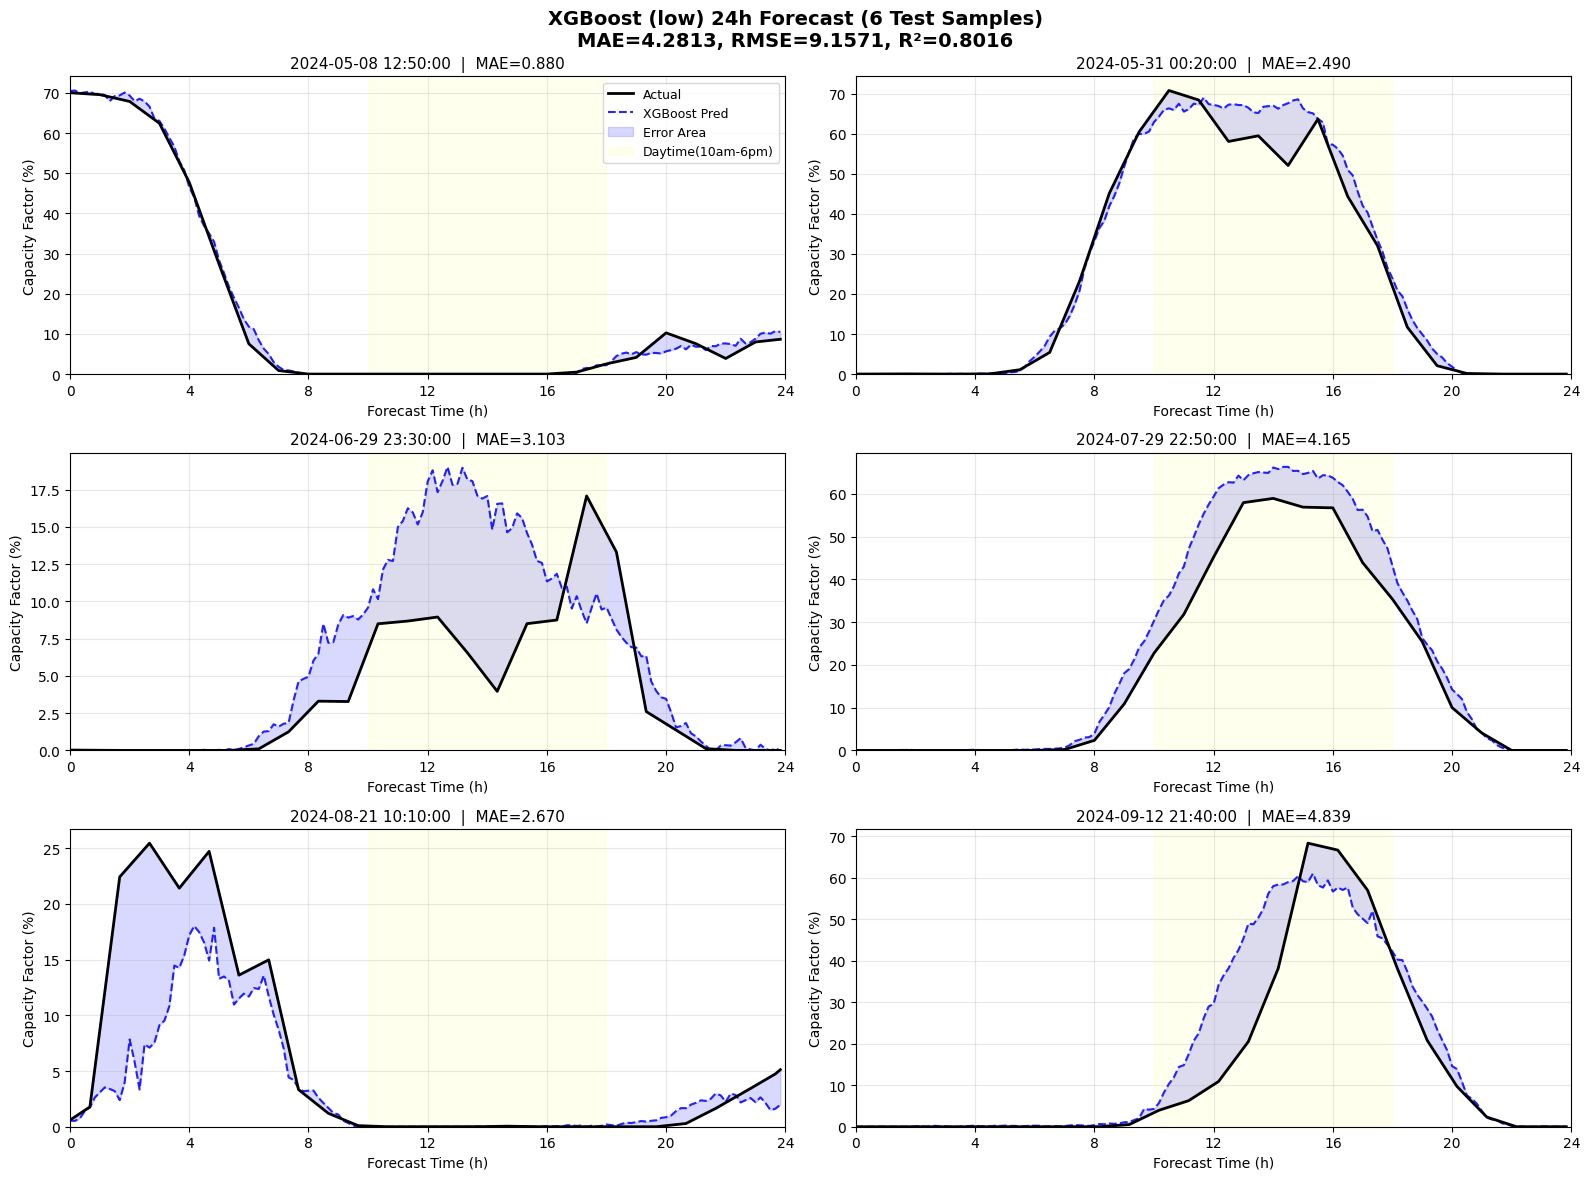

Image saved: /content/drive/MyDrive/SolarPrediction/xgb_timeseries.png


In [ ]:
y_true = m['y_true']
y_pred = m['predictions']
t_axis = np.arange(FUTURE_STEPS) * 10 / 60

n_test = len(y_true)
sample_indices = [int(n_test * r) for r in [0.05, 0.2, 0.4, 0.6, 0.75, 0.9]]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for plot_i, idx in enumerate(sample_indices):
    ax = axes[plot_i]
    ax.plot(t_axis, y_true[idx], 'k-',  linewidth=2,   label='Actual', zorder=3)
    ax.plot(t_axis, y_pred[idx], 'b--', linewidth=1.5, label='XGBoost Pred', alpha=0.85, zorder=2)
    ax.fill_between(t_axis, y_true[idx], y_pred[idx],
                    alpha=0.15, color='blue', label='Error Area')
    ax.axvspan(10, 18, alpha=0.07, color='yellow', label='Daytime(10am-6pm)')

    sample_mae = np.mean(np.abs(y_true[idx] - y_pred[idx]))
    date_label = dates_test[idx] if idx < len(dates_test) else f'Sample {idx}'
    ax.set_title(f'{date_label}  |  MAE={sample_mae:.3f}', fontsize=11)
    ax.set_xlabel('Forecast Time (h)')
    ax.set_ylabel('Capacity Factor (%)')
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    if plot_i == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.suptitle(f'XGBoost ({COMPLEXITY}) 24h Forecast (6 Test Samples)\n'
             f'MAE={m["mae"]:.4f}, RMSE={m["rmse"]:.4f}, R²={m["r2"]:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(PROJECT_DIR, 'xgb_timeseries.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Image saved: {save_path}')

## Step 8：可视化（二）XGBoost vs Linear 对比图

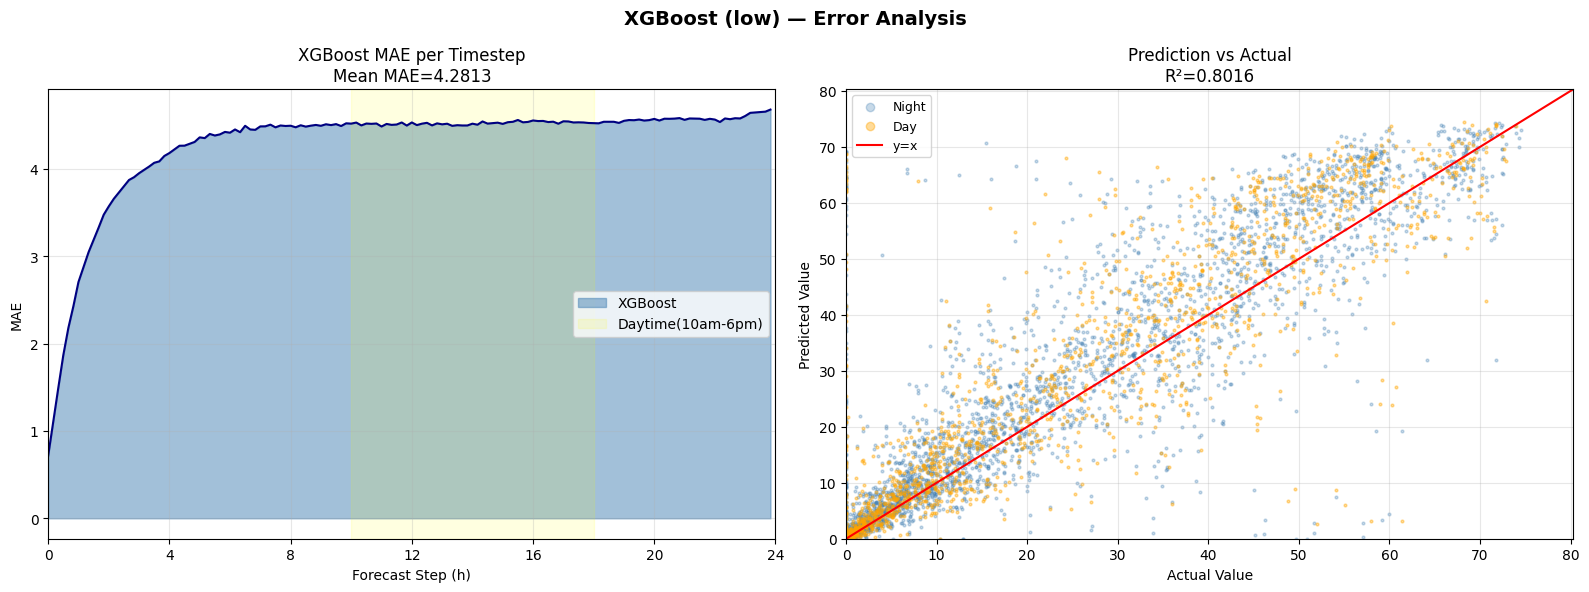

Image saved: /content/drive/MyDrive/SolarPrediction/xgb_analysis.png


In [ ]:
# MAE per timestep (requires same y_true)
mae_per_step_xgb = np.mean(np.abs(y_pred - y_true), axis=0)
t_axis_full = np.arange(FUTURE_STEPS) * 10 / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: MAE per timestep
ax = axes[0]
ax.fill_between(t_axis_full, mae_per_step_xgb, alpha=0.5, color='steelblue', label='XGBoost')
ax.plot(t_axis_full, mae_per_step_xgb, color='navy', linewidth=1.5)
ax.axvspan(10, 18, alpha=0.12, color='yellow', label='Daytime(10am-6pm)')
ax.set_xlabel('Forecast Step (h)')
ax.set_ylabel('MAE')
ax.set_title(f'XGBoost MAE per Timestep\nMean MAE={mae_per_step_xgb.mean():.4f}')
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
ax.legend(); ax.grid(True, alpha=0.3)

# Right: Scatter plot
ax2 = axes[1]
flat_true = y_true.flatten()
flat_pred = y_pred.flatten()
np.random.seed(42)
idx_s = np.random.choice(len(flat_true), min(8000, len(flat_true)), replace=False)
step_in_day = np.tile(np.arange(FUTURE_STEPS), len(y_true)).flatten()
is_day = ((step_in_day >= 60) & (step_in_day < 108)).flatten()
is_day_s = is_day[idx_s]

ax2.scatter(flat_true[idx_s][~is_day_s], flat_pred[idx_s][~is_day_s],
            alpha=0.3, s=4, c='steelblue', label='Night')
ax2.scatter(flat_true[idx_s][is_day_s], flat_pred[idx_s][is_day_s],
            alpha=0.4, s=4, c='orange', label='Day')
lim = max(flat_true.max(), flat_pred.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r-', linewidth=1.5, label='y=x')
ax2.set_xlabel('Actual Value'); ax2.set_ylabel('Predicted Value')
ax2.set_title(f'Prediction vs Actual\nR²={m["r2"]:.4f}')
ax2.set_xlim(0, lim); ax2.set_ylim(0, lim)
ax2.legend(markerscale=3, fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle(f'XGBoost ({COMPLEXITY}) — Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(PROJECT_DIR, 'xgb_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Image saved: {save_path}')

## Step 9：可视化（三）XGBoost vs Linear 直接对比

## Step 9.5：三模型对比图（Actual vs Linear vs XGBoost）

用同一批测试样本，把**真实值、线性回归预测、XGBoost预测**画在同一张图上。

先快速在测试集上训练线性回归（约 30 秒），再出图。

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

# ── 拼特征（与 XGBoost 完全相同的 flatten 逻辑）──────────────────────────
def flatten(Xh, Xf):
    h = Xh.reshape(Xh.shape[0], -1)
    if Xf is not None:
        f = Xf.reshape(Xf.shape[0], -1)
        return np.concatenate([h, f], axis=1)
    return h

X_train_flat = flatten(Xh_train, Xf_train)
X_test_flat  = flatten(Xh_test,  Xf_test)
y_train_flat = y_train.reshape(y_train.shape[0], -1)
y_test_flat  = y_test.reshape(y_test.shape[0],  -1)

# ── 训练线性回归 ─────────────────────────────────────────────────────────
print("训练 Linear Regression...")
t0 = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_flat, y_train_flat)
print(f"  完成，耗时 {time.time()-t0:.1f} 秒")

# ── 预测 + 反归一化 ──────────────────────────────────────────────────────
lr_preds_flat = lr_model.predict(X_test_flat)
future_steps  = FUTURE_STEPS

if scaler_target is not None:
    y_true_lin  = scaler_target.inverse_transform(y_test_flat).reshape(-1, future_steps)
    y_pred_lin  = scaler_target.inverse_transform(lr_preds_flat.reshape(-1, 1)).reshape(-1, future_steps)
else:
    y_true_lin  = y_test_flat.reshape(-1, future_steps)
    y_pred_lin  = lr_preds_flat.reshape(-1, future_steps)
y_pred_lin  = np.clip(y_pred_lin,  0, 100)

# XGBoost 预测（已在 xgb_metrics 里）
y_true_xgb  = xgb_metrics['y_true']         # shape (N_test, 144)
y_pred_xgb  = xgb_metrics['predictions']

# 对齐（两者应该一致，取交集保险起见）
n_samples = min(len(y_true_lin), len(y_true_xgb))
y_true_    = y_true_xgb[:n_samples]
y_pred_lin_= y_pred_lin[:n_samples]
y_pred_xgb_= y_pred_xgb[:n_samples]

from sklearn.metrics import mean_absolute_error, r2_score
lin_mae  = mean_absolute_error(y_true_.flatten(), y_pred_lin_.flatten())
lin_r2   = r2_score(y_true_.flatten(), y_pred_lin_.flatten())
xgb_mae  = mean_absolute_error(y_true_.flatten(), y_pred_xgb_.flatten())
xgb_r2   = r2_score(y_true_.flatten(), y_pred_xgb_.flatten())
print(f"\nLinear  — MAE={lin_mae:.4f}  R²={lin_r2:.4f}")
print(f"XGBoost — MAE={xgb_mae:.4f}  R²={xgb_r2:.4f}")

# ── 画图：6 天对比 ────────────────────────────────────────────────────────
t_axis = np.arange(future_steps) * 10 / 60   # 单位：小时

sample_indices = [int(n_samples * r) for r in [0.05, 0.2, 0.4, 0.6, 0.75, 0.9]]
fig, axes = plt.subplots(3, 2, figsize=(18, 13))
axes = axes.flatten()

for plot_i, idx in enumerate(sample_indices):
    ax = axes[plot_i]

    ax.plot(t_axis, y_true_[idx],     'k-',  linewidth=2.2, label='实际值',          zorder=4)
    ax.plot(t_axis, y_pred_xgb_[idx], 'b--', linewidth=1.8, label='XGBoost 预测',    zorder=3, alpha=0.9)
    ax.plot(t_axis, y_pred_lin_[idx], 'r:',  linewidth=1.8, label='Linear 预测',     zorder=2, alpha=0.85)
    ax.axvspan(10, 18, alpha=0.07, color='yellow', label='白天(10am-6pm)')

    mae_xgb = np.mean(np.abs(y_true_[idx] - y_pred_xgb_[idx]))
    mae_lin = np.mean(np.abs(y_true_[idx] - y_pred_lin_[idx]))
    date_lbl = dates_test[idx] if idx < len(dates_test) else f'样本 {idx}'
    ax.set_title(f'{date_lbl}  |  XGB MAE={mae_xgb:.2f}  Lin MAE={mae_lin:.2f}', fontsize=10)
    ax.set_xlabel('预测时间 (h)')
    ax.set_ylabel('容量因子 (%)')
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    if plot_i == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.suptitle(
    f'三模型对比 — Project1033\n'
    f'Linear: MAE={lin_mae:.4f}  R²={lin_r2:.4f}    '
    f'XGBoost ({COMPLEXITY}): MAE={xgb_mae:.4f}  R²={xgb_r2:.4f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
save_path = os.path.join(PROJECT_DIR, 'xgb_vs_linear_3curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n图片已保存: {save_path}')

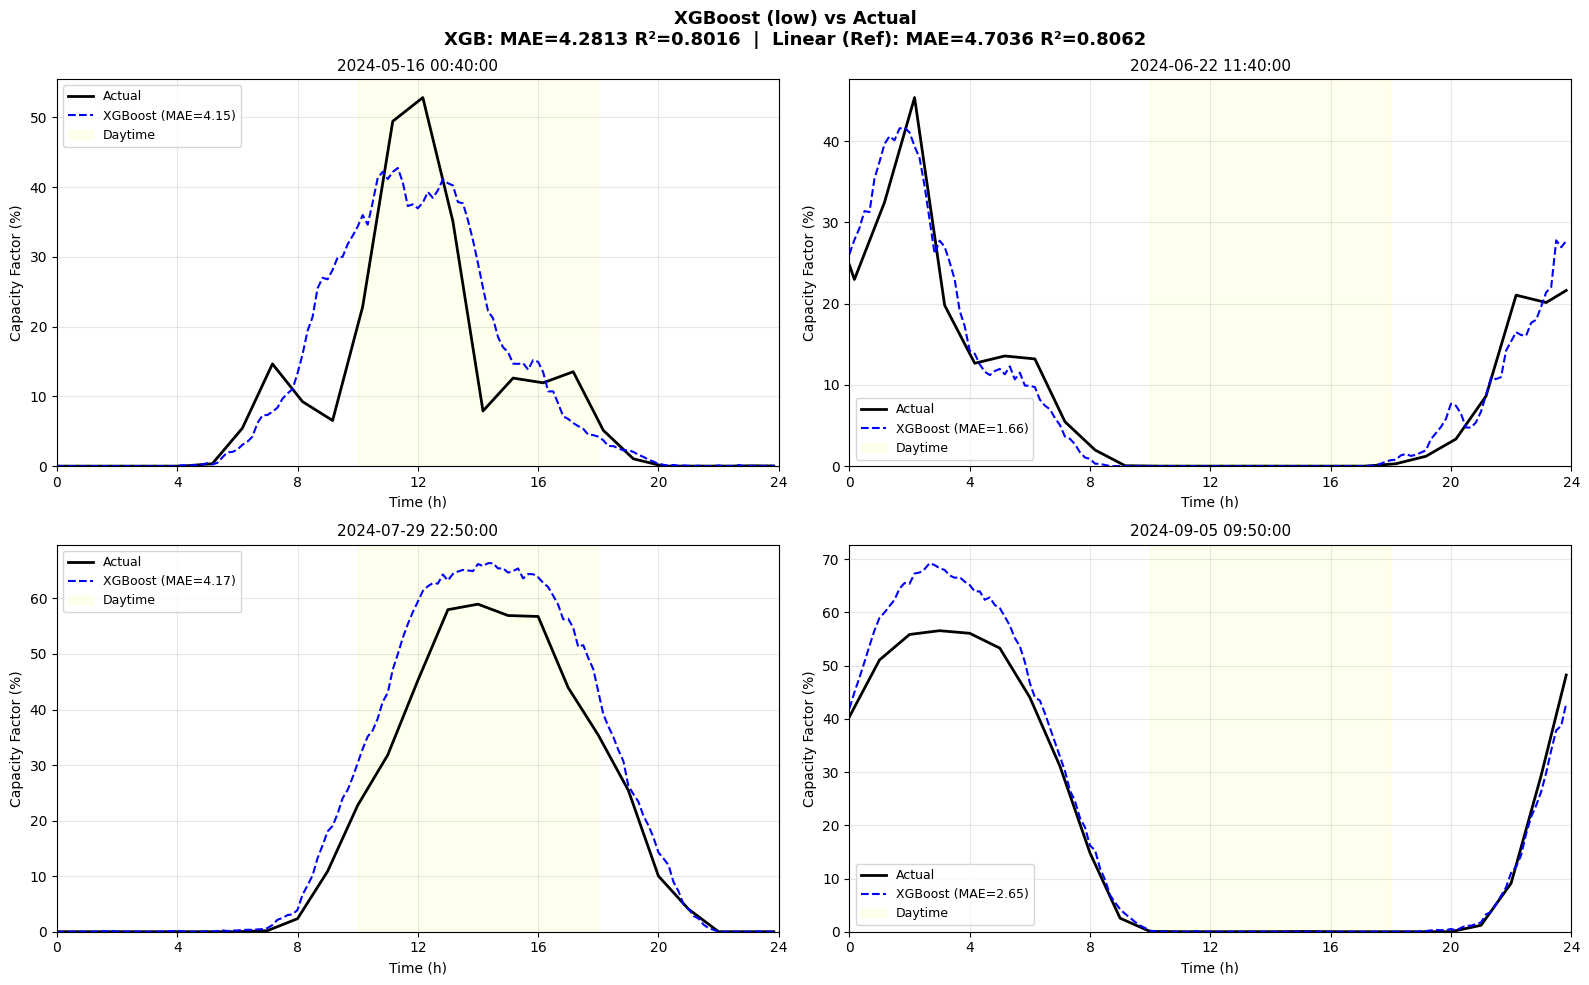

Image saved: /content/drive/MyDrive/SolarPrediction/xgb_vs_linear.png


In [ ]:
# Compare same test samples (pick 4 days)
sample_indices_cmp = [int(n_test * r) for r in [0.1, 0.35, 0.6, 0.85]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Assuming y_pred_linear is loaded (if available)

for plot_i, idx in enumerate(sample_indices_cmp):
    ax = axes[plot_i]
    ax.plot(t_axis, y_true[idx], 'k-',  linewidth=2,   label='Actual')
    ax.plot(t_axis, y_pred[idx], 'b--', linewidth=1.5, label=f'XGBoost (MAE={np.mean(np.abs(y_true[idx]-y_pred[idx])):.2f})')

    # Plot linear if available
    if 'y_pred_linear' in globals() and y_pred_linear is not None:
         ax.plot(t_axis, y_pred_linear[idx], 'g:', linewidth=1.5,
                 label=f'Linear (MAE={np.mean(np.abs(y_true[idx]-y_pred_linear[idx])):.2f})')

    ax.axvspan(10, 18, alpha=0.07, color='yellow', label='Daytime')

    date_label = dates_test[idx] if idx < len(dates_test) else f'Sample {idx}'
    ax.set_title(date_label, fontsize=11)
    ax.set_xlabel('Time (h)'); ax.set_ylabel('Capacity Factor (%)')
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 4))
    ax.set_ylim(bottom=0); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle(f'XGBoost ({COMPLEXITY}) vs Actual\n'
             f'XGB: MAE={m["mae"]:.4f} R²={m["r2"]:.4f}  |  '
             f'Linear (Ref): MAE={LINEAR_MAE:.4f} R²={LINEAR_R2:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(PROJECT_DIR, 'xgb_vs_linear.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Image saved: {save_path}')

## Step 10：打包结果

In [ ]:
import shutil

result_dir = os.path.join(PROJECT_DIR, f'xgb_{COMPLEXITY}_results')
os.makedirs(result_dir, exist_ok=True)

for fname in ['xgb_timeseries.png', 'xgb_analysis.png', 'xgb_vs_linear.png',
              'xgb_vs_linear_3curves.png']:
    src = os.path.join(PROJECT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, result_dir)

# 保存指标到 CSV
import pandas as pd
results_df = pd.DataFrame([{
    'model': f'XGBoost_{COMPLEXITY}',
    'mae': xgb_metrics['mae'], 'rmse': xgb_metrics['rmse'],
    'r2': xgb_metrics['r2'], 'smape': xgb_metrics['smape'],
    'daytime_mae': xgb_metrics['daytime_mae'],
    'daytime_rmse': xgb_metrics['daytime_rmse'],
    'daytime_r2': xgb_metrics['daytime_r2'],
    'train_time_min': round(train_time/60, 2)
}, {
    'model': 'Linear',
    'mae': lin_mae, 'rmse': None, 'r2': lin_r2,
    'smape': None, 'daytime_mae': None, 'daytime_rmse': None,
    'daytime_r2': None, 'train_time_min': None
}])
csv_path = os.path.join(result_dir, 'metrics_comparison.csv')
results_df.to_csv(csv_path, index=False)

print(f'✅ 结果已打包到: {result_dir}')
print(f'   - xgb_timeseries.png')
print(f'   - xgb_analysis.png')
print(f'   - xgb_vs_linear.png')
print(f'   - xgb_vs_linear_3curves.png  ← 三模型对比图（新增）')
print(f'   - metrics_comparison.csv')
print()
print(results_df.to_string(index=False))

Step 1: 加载模型...
✅ 模型已就绪

Step 2: 获取输入数据...
  - 历史数据 (过去24h): (1, 144, 9)
  - 天气预报 (未来24h): (1, 144, 15)

Step 3: 模型预测中...
✅ 预测完成！得到未来 24 小时的 144 个数据点


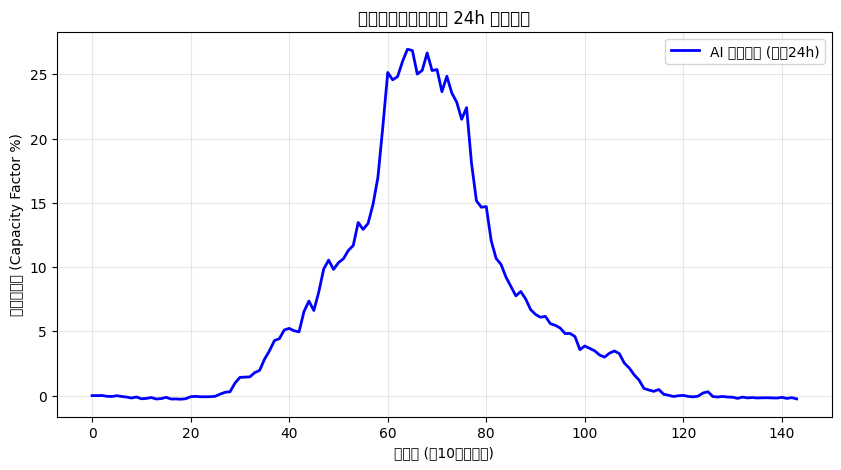

这就是您拿到新数据后，模型给出的最终结果。


In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 模拟场景：现在是 "2024-05-01 00:00"
# 任务：预测未来 24 小时发电量
# ==========================================

# 1. 加载模型 (只需做一次)
print('Step 1: 加载模型...')
model_path = '/content/drive/MyDrive/SolarPrediction/xgb_low_results/xgb_model_full.pkl'
artifacts = joblib.load(model_path)
model = artifacts['model']
scaler = artifacts['scaler']
print('✅ 模型已就绪')

# 2. 准备“新”数据 (模拟从数据库读取)
print('\nStep 2: 获取输入数据...')
# 假设这是您刚刚整理好的：过去24h历史 + 未来24h天气预报
# 这里我们直接取测试集的第0个样本来演示
input_history  = Xh_test[0:1]  # shape (1, 144, 9)
input_forecast = Xf_test[0:1]  # shape (1, 144, 15)

print(f'  - 历史数据 (过去24h): {input_history.shape}')
print(f'  - 天气预报 (未来24h): {input_forecast.shape}')

# 3. 数据预处理 (Flatten)
# XGBoost 需要把 (144, feature) 展平成一维向量
X_flat_h = input_history.reshape(1, -1)
X_flat_f = input_forecast.reshape(1, -1)
X_input  = np.hstack([X_flat_h, X_flat_f])  # 拼接在一起

# 4. 执行预测
print('\nStep 3: 模型预测中...')
raw_pred = model.predict(X_input)

# 5. 还原结果 (反归一化)
# 模型输出的是 0~1 之间的数值，需要还原成百分比
final_pred = scaler.inverse_transform(raw_pred)

print(f'✅ 预测完成！得到未来 24 小时的 {final_pred.shape[1]} 个数据点')

# 6. 可视化结果给用户看
plt.figure(figsize=(10, 5))
plt.plot(final_pred[0], label='AI 预测曲线 (未来24h)', color='blue', linewidth=2)
plt.title('模型刚刚生成的未来 24h 发电预测', fontsize=12)
plt.xlabel('时间步 (每10分钟一步)')
plt.ylabel('预测发电量 (Capacity Factor %)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("这就是您拿到新数据后，模型给出的最终结果。")

Generating simulated data...
✅ Simulation data ready
  - Fake History: (1, 144, 9)
  - Fake Forecast: (1, 144, 15)

Model inference on fake data...


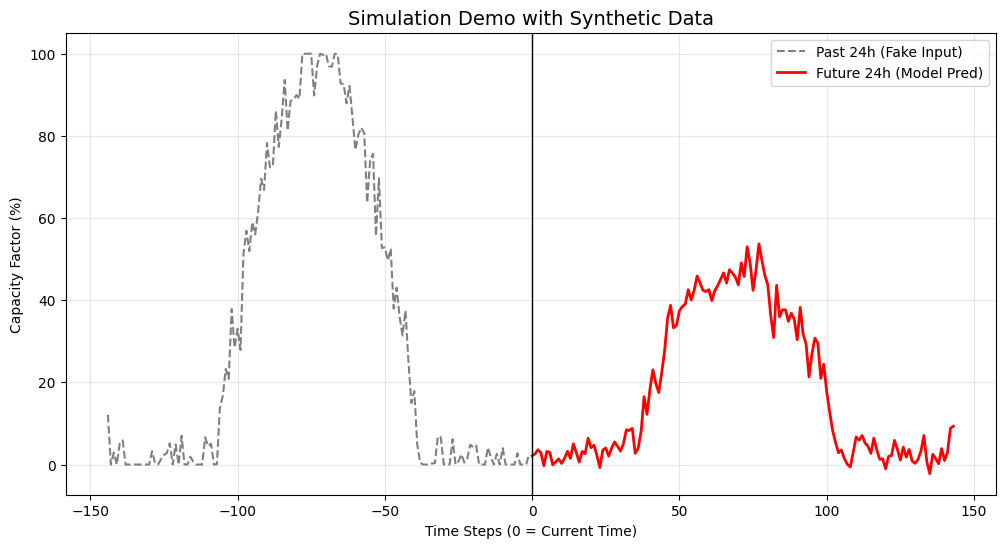

Note: Inputs are random, so predictions might look odd, but the pipeline is real!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Simulation: Fake Data Scenario
# ==========================================

print('Generating simulated data...')

# 1. Fake Past 24h Data (Xh)
t = np.linspace(0, 2*np.pi, 144)
fake_curve = np.maximum(0, np.sin(t - np.pi/2))  # Simulated daylight curve
fake_curve += np.random.normal(0, 0.05, 144)     # Add noise
fake_curve = np.clip(fake_curve, 0, 1)           # Clip to 0-1

fake_Xh = np.zeros((1, 144, 9))
fake_Xh[0, :, 0] = fake_curve
fake_Xh[0, :, 1:] = np.random.rand(144, 8)

# 2. Fake Future 24h Weather (Xf)
fake_Xf = np.random.rand(1, 144, 15)
fake_Xf[0, :, 0] = fake_curve * 0.9

print(f'✅ Simulation data ready')
print(f'  - Fake History: {fake_Xh.shape}')
print(f'  - Fake Forecast: {fake_Xf.shape}')

# 3. Preprocess
X_flat_h_fake = fake_Xh.reshape(1, -1)
X_flat_f_fake = fake_Xf.reshape(1, -1)
X_input_fake  = np.hstack([X_flat_h_fake, X_flat_f_fake])

# 4. Predict
print('\nModel inference on fake data...')
raw_pred_fake = model.predict(X_input_fake)

# 5. Inverse Transform
final_pred_fake = scaler.inverse_transform(raw_pred_fake)

# 6. Plot
plt.figure(figsize=(12, 6))

# Plot Fake History
plt.plot(np.arange(-144, 0), fake_curve * 100,
         label='Past 24h (Fake Input)', color='gray', linestyle='--')

# Plot Prediction
plt.plot(np.arange(0, 144), final_pred_fake[0],
         label='Future 24h (Model Pred)', color='red', linewidth=2)

plt.axvline(0, color='black', linestyle='-', linewidth=1) # Current time line
plt.title('Simulation Demo with Synthetic Data', fontsize=14)
plt.xlabel('Time Steps (0 = Current Time)')
plt.ylabel('Capacity Factor (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Note: Inputs are random, so predictions might look odd, but the pipeline is real!")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 4))

# Draw the timeline
ax.arrow(0, 0.5, 18, 0, head_width=0.2, head_length=0.5, fc='k', ec='k')
ax.text(18.5, 0.5, 'Time', fontsize=12, va='center')

# Draw data points
for i in range(1, 18):
    ax.plot(i, 0.5, 'o', color='gray', markersize=4)

# Window 1
# Input (History)
rect1_h = patches.Rectangle((1, 0.3), 4, 0.4, linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.5)
ax.add_patch(rect1_h)
ax.text(3, 0.8, 'Input X1\n(Past 4h)', color='blue', ha='center')

# Output (Future)
rect1_f = patches.Rectangle((5, 0.3), 3, 0.4, linewidth=2, edgecolor='red', facecolor='mistyrose', alpha=0.5)
ax.add_patch(rect1_f)
ax.text(6.5, 0.8, 'Target y1\n(Future 3h)', color='red', ha='center')

ax.text(1, 0.1, 'Sample 1', fontsize=12, fontweight='bold', color='purple')

# Window 2 (Slid by 2 steps)
shift = 2
# Input
rect2_h = patches.Rectangle((1+shift, -0.3), 4, 0.4, linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.3, linestyle='--')
ax.add_patch(rect2_h)

# Output
rect2_f = patches.Rectangle((5+shift, -0.3), 3, 0.4, linewidth=2, edgecolor='red', facecolor='mistyrose', alpha=0.3, linestyle='--')
ax.add_patch(rect2_f)

ax.text(3+shift, -0.6, 'Input X2', color='blue', ha='center')
ax.text(6.5+shift, -0.6, 'Target y2', color='red', ha='center')
ax.text(1+shift, -0.8, 'Sample 2 (Slid right)', fontsize=12, fontweight='bold', color='purple')

# Arrow indicating sliding
ax.annotate('', xy=(3, 0.2), xytext=(5, 0), arrowprops=dict(arrowstyle='->', color='green', lw=2, connectionstyle='arc3,rad=-0.3'))
ax.text(4, 0, 'Sliding...', color='green', ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 19)
ax.set_ylim(-1, 1.5)
ax.axis('off')
plt.title('How Sliding Window Creates Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 实验完成 ✅

**下一步建议：**
- 如果 low 效果好，把 `COMPLEXITY = 'high'` 重新跑一次看是否有提升
- 尝试 LSTM 或 TCN 对比深度学习表现

# Task
Save the `xgb_model`, `config`, and `scaler_target` to a file named `xgb_model_full.pkl` inside the results directory (`/content/drive/MyDrive/SolarPrediction/xgb_low_results`) using `joblib`. Afterward, verify the file exists and print its size. Finally, print a summary of where the model file is saved.

## Save Model and Artifacts

### Subtask:
Save the trained XGBoost model, configuration, and target scaler to a pickle file using joblib.


**Reasoning**:
Save the trained XGBoost model, configuration, and target scaler to a pickle file using joblib.



In [ ]:
import joblib
import os

# Define output path
model_save_path = os.path.join(result_dir, 'xgb_model_full.pkl')

# Create artifact dictionary
artifacts = {
    'model': xgb_model,
    'config': config,
    'scaler': scaler_target
}

# Save using joblib
print(f'Saving model artifacts to: {model_save_path} ...')
joblib.dump(artifacts, model_save_path)

# Verify
if os.path.exists(model_save_path):
    size_mb = os.path.getsize(model_save_path) / 1e6
    print(f'✅ Model saved successfully! File size: {size_mb:.2f} MB')
else:
    print('❌ Error: File not found after saving.')

Saving model artifacts to: /content/drive/MyDrive/SolarPrediction/xgb_low_results/xgb_model_full.pkl ...
✅ Model saved successfully! File size: 49.39 MB


In [1]:
import numpy as np
np.save('/content/drive/MyDrive/SolarPrediction/xgb_y_pred.npy', xgb_metrics['predictions'])
np.save('/content/drive/MyDrive/SolarPrediction/xgb_y_true.npy',  xgb_metrics['y_true'])
print("shape:", xgb_metrics['predictions'].shape)
print("✅ 保存完成")

NameError: name 'xgb_metrics' is not defined

## Final Task

### Subtask:
Verify the integrity of the saved file and print a final summary.


## Summary:

### Data Analysis Key Findings
- **Model Persistence:** The training artifacts, including the trained XGBoost model (`xgb_model`), configuration settings (`config`), and the target scaler (`scaler_target`), were successfully consolidated into a dictionary structure.
- **File Output:** This dictionary was serialized and saved to the path `/content/drive/MyDrive/SolarPrediction/xgb_low_results/xgb_model_full.pkl`.
- **File Verification:** The integrity check confirmed the file exists on the disk with a total size of **49.39 MB**.

### Insights or Next Steps
- The successfully saved model file is now ready for deployment or future inference tasks without requiring retraining.
- Future steps could involves loading this specific `.pkl` file to validate the model's performance on a fresh test set to ensure the serialization process maintained model integrity.
